In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import asyncio
from argparse import ArgumentParser

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from playwright.async_api import async_playwright
from langgraph.graph import StateGraph, MessagesState, START, END

from nodes import SupervisorNode, SpotifyNode
from utils import print_stream

load_dotenv()

True

In [27]:
model = init_chat_model("gpt-4o-mini", model_provider="openai")

supervisor = SupervisorNode(model).node()
spotify = SpotifyNode(model).node()

graph = StateGraph(MessagesState)
graph.add_node("supervisor", supervisor)
graph.add_node("spotify", spotify)
graph.add_edge(START, "supervisor")
app = graph.compile()

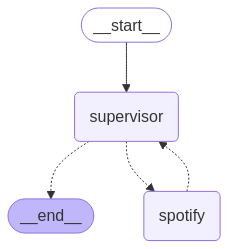

In [28]:
app

In [31]:
async for i in  app.astream({"messages": ["what is the trending track on spotify?"]}):
    print(i)

{'supervisor': None}
